<a href="https://colab.research.google.com/github/Neil-Cardoz/Sem_4/blob/main/SML_Support_Vector_Machine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [45]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from sklearn import svm
from sklearn.model_selection import GridSearchCV
from sklearn import metrics

In [46]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/CSV_FILES/heart (1).csv")

In [47]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


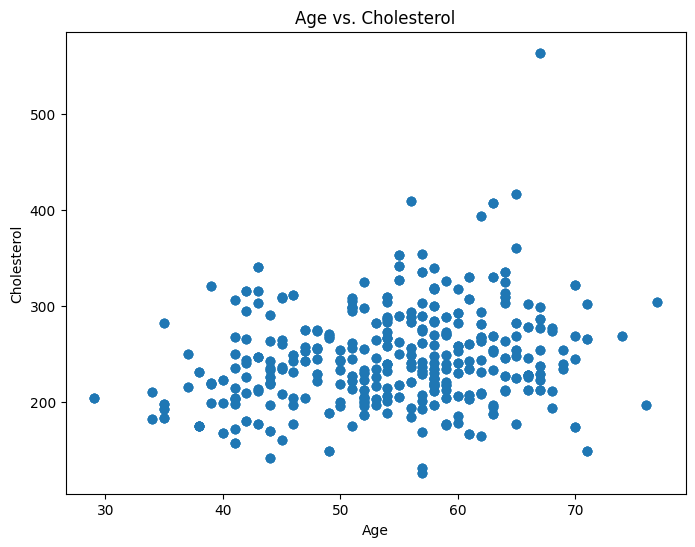

In [48]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(df['age'], df['chol'])
plt.xlabel('Age')
plt.ylabel('Cholesterol')
plt.title('Age vs. Cholesterol')
plt.show()


In [49]:
x = df.drop(columns='target', axis=1)
y = df['target']

In [50]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [51]:
from sklearn import svm
from sklearn.model_selection import GridSearchCV

In [52]:
# create a svm classifier and hyper parameter tuning

# Create an SVM classifier
model = svm.SVC()

# Define the parameter grid for hyperparameter tuning
param_grid = {'C': [1, 10, 100, 1000, 10000],
              'gamma': [1, 0.1, 0.01, 0.001, 0.0001],
              'kernel': ['rbf']}

# Create a GridSearchCV object
grid = GridSearchCV(model, param_grid, refit=True, verbose=1, cv=15)

# Fit the grid search to the training data
grid_search = grid.fit(x_train, y_train)

# Print the best parameters found
print(grid.best_params_)

accuracy = grid_search.best_score_ * 100
print("Accuracy: {:.2f}%".format(accuracy))




Fitting 15 folds for each of 25 candidates, totalling 375 fits
{'C': 1000, 'gamma': 0.001, 'kernel': 'rbf'}
Accuracy: 98.17%


In [53]:
y_test_hat = grid_search.predict(x_test)
test_accuracy = accuracy_score(y_test, y_test_hat)*100
print("Test Accuracy: {:.2f}%".format(test_accuracy))
test_accuracy
print("Accuracy for training dataset :", grid_search.best_score_*100)


Test Accuracy: 100.00%
Accuracy for training dataset : 98.17059483726152


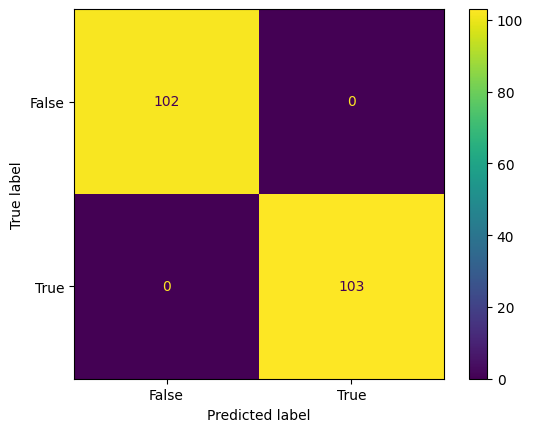

In [54]:
confusion_matrix = metrics.confusion_matrix(y_test, y_test_hat)
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = [False, True])
cm_display.plot()
plt.show()